# **Segment Analysis**

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from dotenv import load_dotenv
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.compute as pc
import gc

In [2]:
sys.path.append(os.path.abspath("../src"))
from estimator import SegmentEstimator

In [28]:
load_dotenv()
PROPENSITY_PATH = os.getenv("PROPENSITY_PATH")
propensity_path = PROPENSITY_PATH
CSV_PATH = os.getenv("CSV_PATH")
csv_path = CSV_PATH


In [4]:
run_segment_cols = [
    'propensity',
    'is_algo',
    'y_like_24h',
    'y_dislike_24h'
]

distribution_cols = ['propensity',
        'is_algo'
]

smd_cols = [
    'propensity',
    'is_algo',
    'u_algo_rate_smoothed',
    'u_item_seen_before',
    'item_like_rate_smoothed',
    'u_like_rate_smoothed',
    'log_item_prior_plays',
    'log_u_prior_plays',
    'u_dislike_rate_smoothed',
    'item_dislike_rate_smoothed'
]

smd_plot_cols = [
    'u_algo_rate_smoothed',
    'u_item_seen_before',
    'item_like_rate_smoothed',
    'u_like_rate_smoothed',
    'log_item_prior_plays',
    'log_u_prior_plays',
    'u_dislike_rate_smoothed',
    'item_dislike_rate_smoothed'
]

### **Core Drivers**

In [5]:
estimator = SegmentEstimator(propensity_path)

# user_average_segment × item_very_popular_segment
segment_1 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "log_item_prior_plays > 3"]

# user_average_segment × rare_likers_segment
segment_2 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# item_popular_segment × rare_likers_segment
segment_3 = ["log_item_prior_plays > 1 AND log_item_prior_plays <= 3",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# item_very_popular_segment × rare_likers_segment
segment_4 =  ["log_item_prior_plays > 3",
              "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# user_average_segment × item_popular_segment × rare_likers_segment
segment_5 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "log_item_prior_plays > 1 AND log_item_prior_plays <= 3",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

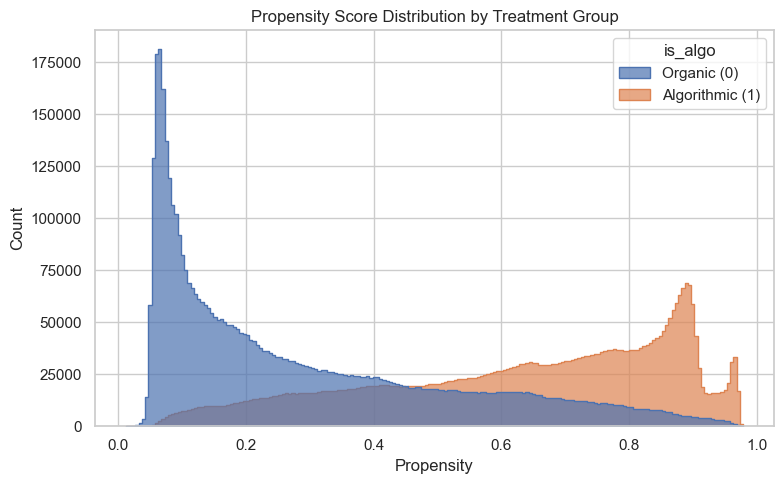

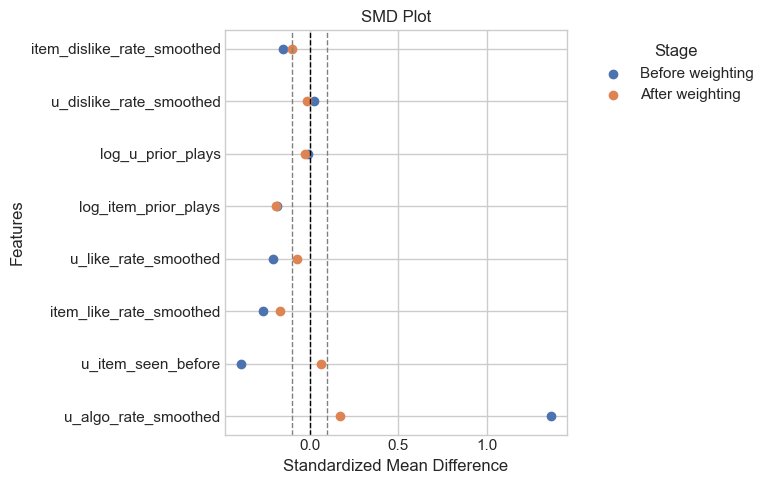

,metric,value
0,n_original,9256718
1,n_trimmed,9256718
2,pct_dropped,0.0 %
3,propensity_min,0.01259
4,propensity_max,0.97784
5,ESS,5216417.524
6,ATE_like,0.0094
7,ATE_dislike,0.00067


In [6]:
# segment 1
segment_1_df = estimator.load_segment(segment_1,distribution_cols)
estimator.propensity_distribution_plot(segment_1_df)
del segment_1_df
segment_1_df = estimator.load_segment(segment_1,smd_cols)
estimator.smd_plot(segment_1_df, smd_plot_cols)
del segment_1_df
segment_1_df = estimator.load_segment(segment_1,run_segment_cols)
result_1 = estimator.run_segment(segment_1_df)
del segment_1_df
gc.collect()
result_1


- SMDs drop after IPTW, meaning treated and control groups become more comparable
- Algorithmic recommendations increase likes by +9.4 per 1,000 listens while increasing dislikes only by +0.67 per 1,000; clear positive net benefit for algorithmic recommendations in this segment



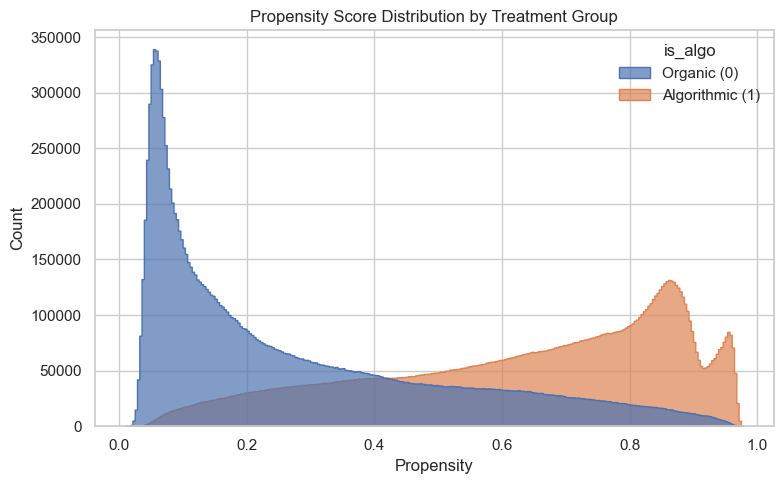

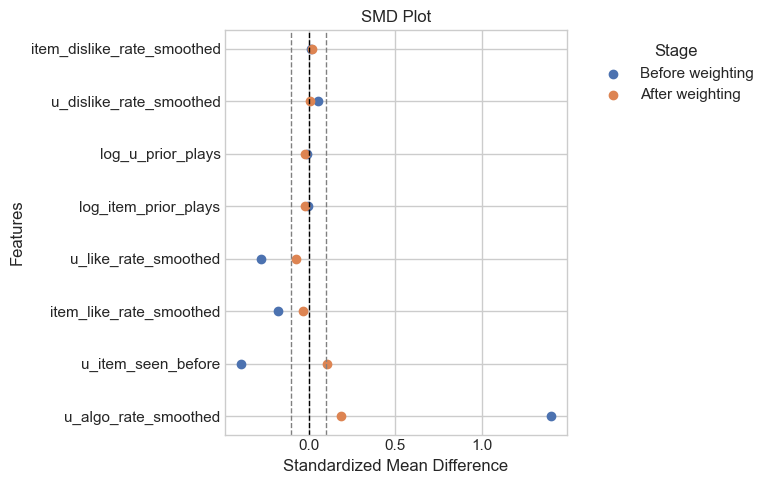

,metric,value
0,n_original,29609372
1,n_trimmed,29609335
2,pct_dropped,0.00012 %
3,propensity_min,0.00461
4,propensity_max,0.97784
5,ESS,16218250.755
6,ATE_like,0.00909
7,ATE_dislike,0.00124


In [7]:
# segment 2
segment_2_df = estimator.load_segment(segment_2,distribution_cols)
estimator.propensity_distribution_plot(segment_2_df)
del segment_2_df
segment_2_df = estimator.load_segment(segment_2,smd_cols)
estimator.smd_plot(segment_2_df, smd_plot_cols)
del segment_2_df
segment_2_df = estimator.load_segment(segment_2,run_segment_cols)
result_2 = estimator.run_segment(segment_2_df)
del segment_2_df
gc.collect()
result_2

- IPTW reduces initial covariate imbalance, suggesting treated and control groups are reasonably comparable after weighting
- Algorithmic recommendations increase likes by +9.1 per 1,000 listens while also increasing dislikes by +1.24 per 1,000; algorithmic exposure improves overall engagement


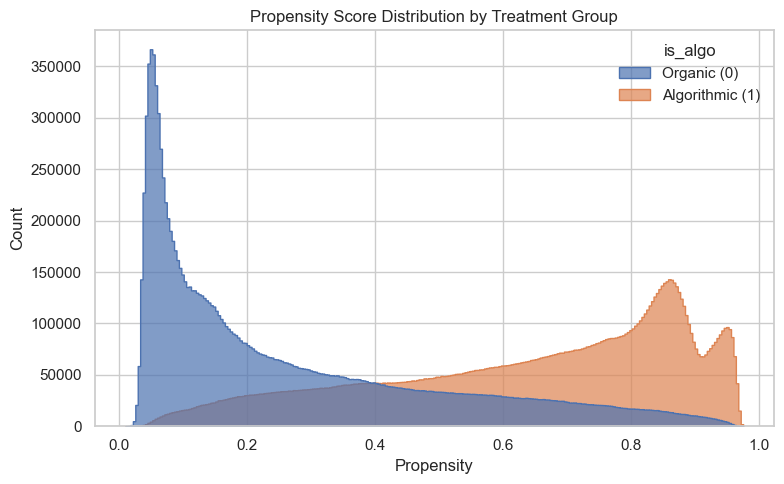

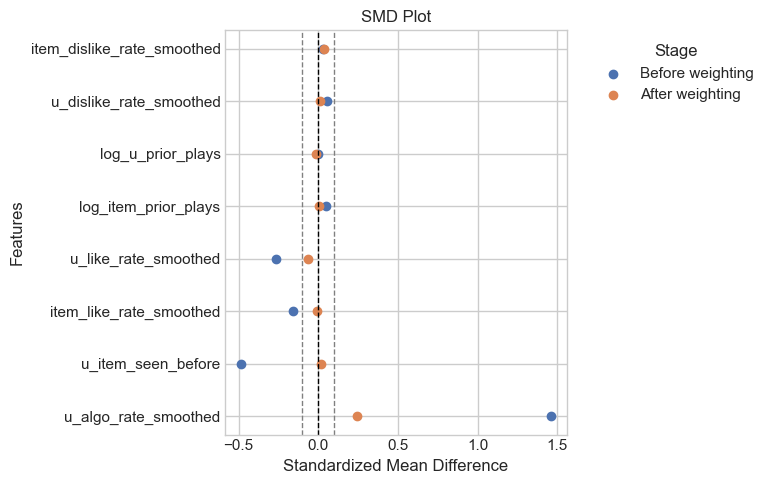

,metric,value
0,n_original,27520754
1,n_trimmed,27520720
2,pct_dropped,0.00012 %
3,propensity_min,0.00461
4,propensity_max,0.97462
5,ESS,15110569.289
6,ATE_like,0.00925
7,ATE_dislike,0.00152


In [8]:
# segment 3
segment_3_df = estimator.load_segment(segment_3,distribution_cols)
estimator.propensity_distribution_plot(segment_3_df)
del segment_3_df
segment_3_df = estimator.load_segment(segment_3,smd_cols)
estimator.smd_plot(segment_3_df, smd_plot_cols)
del segment_3_df
segment_3_df = estimator.load_segment(segment_3,run_segment_cols)
result_3 = estimator.run_segment(segment_3_df)
del segment_3_df
gc.collect()
result_3

- IPTW reduces most covariate imbalances, meaning treated and control groups are reasonably comparable
- Algorithmic recommendations increase likes by +9.3 per 1,000 listens but also increase dislikes by +1.5 per 1,000; overall engagement improvement for this segment

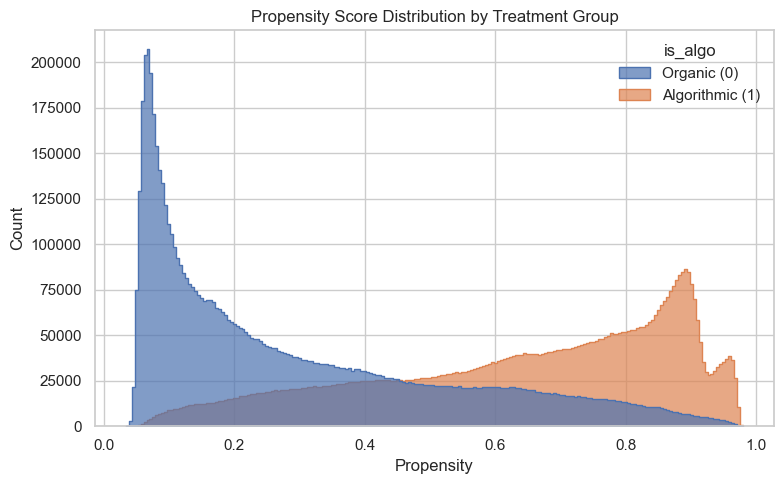

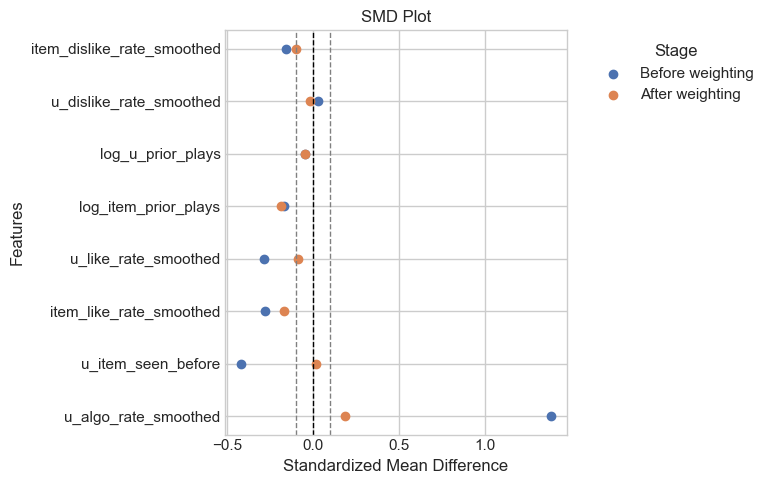

,metric,value
0,n_original,13670051
1,n_trimmed,13670051
2,pct_dropped,0.0 %
3,propensity_min,0.03342
4,propensity_max,0.97993
5,ESS,7749980.418
6,ATE_like,0.00791
7,ATE_dislike,0.00082


In [9]:
# segment 4
segment_4_df = estimator.load_segment(segment_4,distribution_cols)
estimator.propensity_distribution_plot(segment_4_df)
del segment_4_df
segment_4_df = estimator.load_segment(segment_4,smd_cols)
estimator.smd_plot(segment_4_df, smd_plot_cols)
del segment_4_df
segment_4_df = estimator.load_segment(segment_4,run_segment_cols)
result_4 = estimator.run_segment(segment_4_df)
del segment_4_df
gc.collect()
result_4

- A few covariates are within the threshold, but several remain outside it, so this segment should not be presented as well balanced
- Algorithmic recommendations increase likes by +7.9 per 1,000 listens and dislikes by +0.82 per 1,000 listens within this segment; estimate should be interpreted with some caution


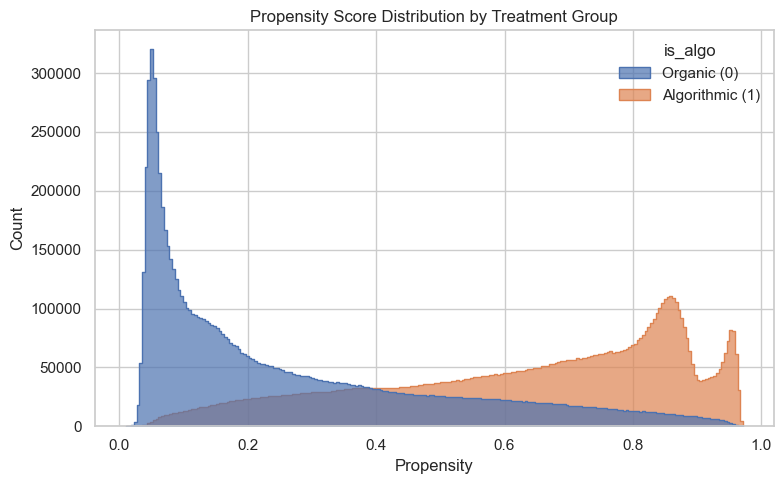

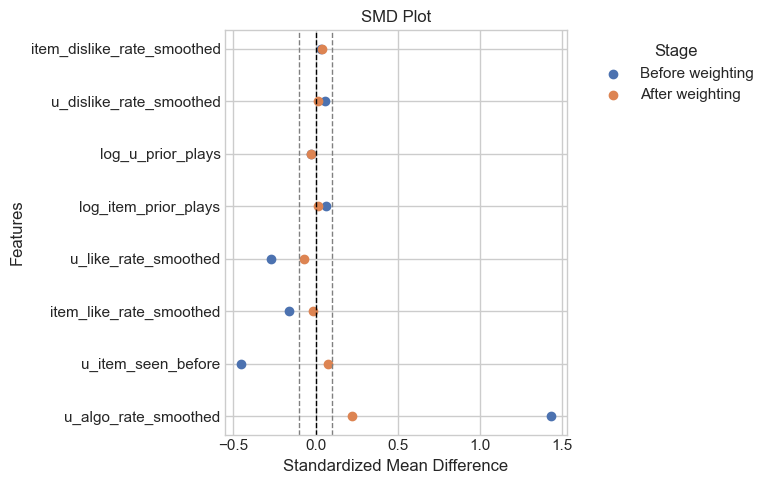

,metric,value
0,n_original,18346641
1,n_trimmed,18346619
2,pct_dropped,0.00012 %
3,propensity_min,0.00461
4,propensity_max,0.97156
5,ESS,10021270.699
6,ATE_like,0.00946
7,ATE_dislike,0.00151


In [10]:
# segment 5
segment_5_df = estimator.load_segment(segment_5,distribution_cols)
estimator.propensity_distribution_plot(segment_5_df)
del segment_5_df
segment_5_df = estimator.load_segment(segment_5,smd_cols)
estimator.smd_plot(segment_5_df, smd_plot_cols)
del segment_5_df
segment_5_df = estimator.load_segment(segment_5,run_segment_cols)
result_5 = estimator.run_segment(segment_5_df)
del segment_5_df
gc.collect()
result_5

- IPTW reduces most initial imbalance, but some remain imbalanced, indicating potential residual confounding in this segment 
- Algorithmic recommendations increase likes by +9.5 per 1,000 listens and dislikes by +1.5 per 1,000 listens in this segment, estimates should be interpreted with some caution

### **Risk Segments**

In [11]:
# user_light_segment × item_niche_segment × rare_likers_segment
segment_6 = ["log_u_prior_plays >= 0 AND log_u_prior_plays <= 3",
             "log_item_prior_plays > 0.2 AND log_item_prior_plays <= 1",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# item_new_segment × rare_likers_segment
segment_7 = ["log_item_prior_plays >= 0 AND log_item_prior_plays <= 0.2",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# user_average_segment × item_new_segment
segment_8 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "log_item_prior_plays >= 0 AND log_item_prior_plays <= 0.2"]

# user_average_segment × item_new_segment × rare_likers_segment
segment_9 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "log_item_prior_plays >= 0 AND log_item_prior_plays <= 0.2",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]


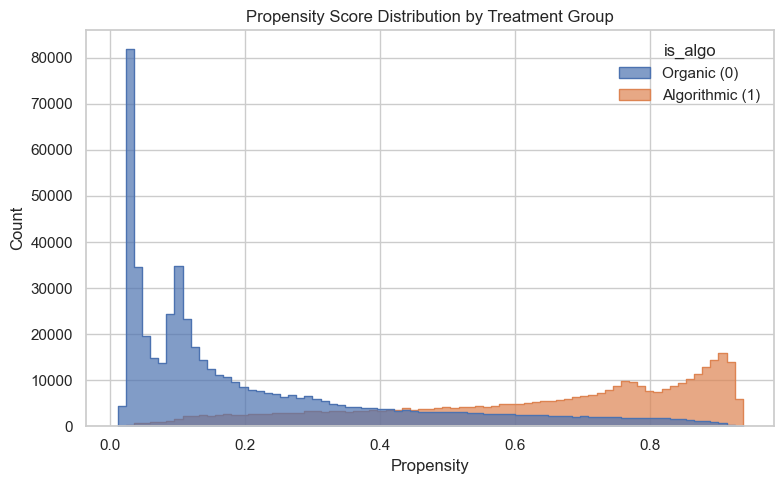

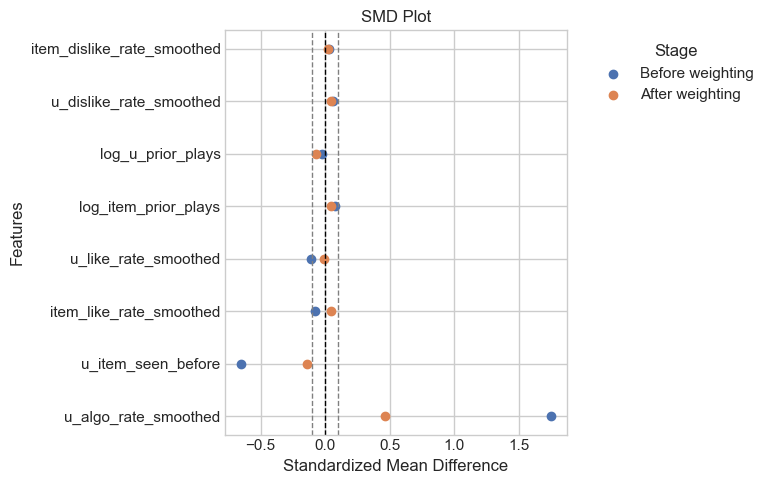

,metric,value
0,n_original,905999
1,n_trimmed,905999
2,pct_dropped,0.0 %
3,propensity_min,0.01082
4,propensity_max,0.93665
5,ESS,466438.448
6,ATE_like,0.00922
7,ATE_dislike,0.00202


In [12]:
# segment 6
segment_6_df = estimator.load_segment(segment_6,distribution_cols)
estimator.propensity_distribution_plot(segment_6_df)
del segment_6_df
segment_6_df = estimator.load_segment(segment_6,smd_cols)
estimator.smd_plot(segment_6_df, smd_plot_cols)
del segment_6_df
segment_6_df = estimator.load_segment(segment_6,run_segment_cols)
result_6 = estimator.run_segment(segment_6_df)
del segment_6_df
gc.collect()
result_6

- Propensity distributions show clear separation between algorithmic and organic exposure, with a narrower overlap region compared to high-volume segments
- IPTW reduces some pre-treatment imbalance, but several covariates remain outside the threshold
- Algorithmic recommendations increase likes by +9.2 per 1,000 listens but also increase dislikes by +2.0 per 1,000 listens, which is a noticeably larger dislike increase than in previous segments


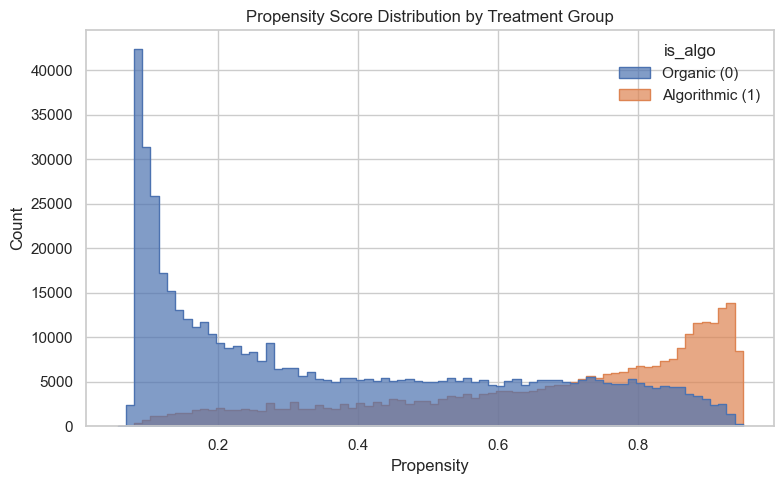

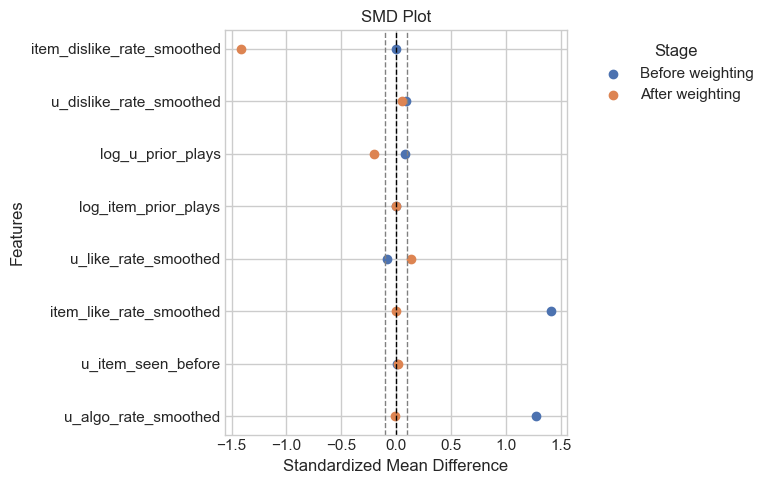

,metric,value
0,n_original,833382
1,n_trimmed,833382
2,pct_dropped,0.0 %
3,propensity_min,0.05676
4,propensity_max,0.94874
5,ESS,492233.926
6,ATE_like,0.00686
7,ATE_dislike,0.00306


In [13]:
# segment 7
segment_7_df = estimator.load_segment(segment_7,distribution_cols)
estimator.propensity_distribution_plot(segment_7_df)
del segment_7_df
segment_7_df = estimator.load_segment(segment_7,smd_cols)
estimator.smd_plot(segment_7_df, smd_plot_cols)
del segment_7_df
segment_7_df = estimator.load_segment(segment_7,run_segment_cols)
result_7 = estimator.run_segment(segment_7_df)
del segment_7_df
gc.collect()
result_7

- Propensity distributions show clear separation between organic and algorithmic exposure, with a relatively limited overlap region
- IPTW improves balance for some covariates, but 2 variables remain outside the threshold, suggesting residual imbalance
- Algorithmic recommendations increase likes by +6.9 per 1,000 listens but also increase dislikes by +3.1 per 1,000 listens

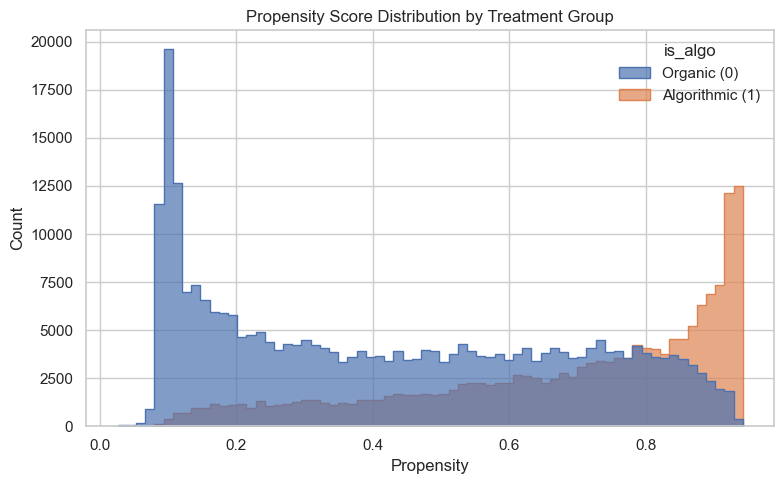

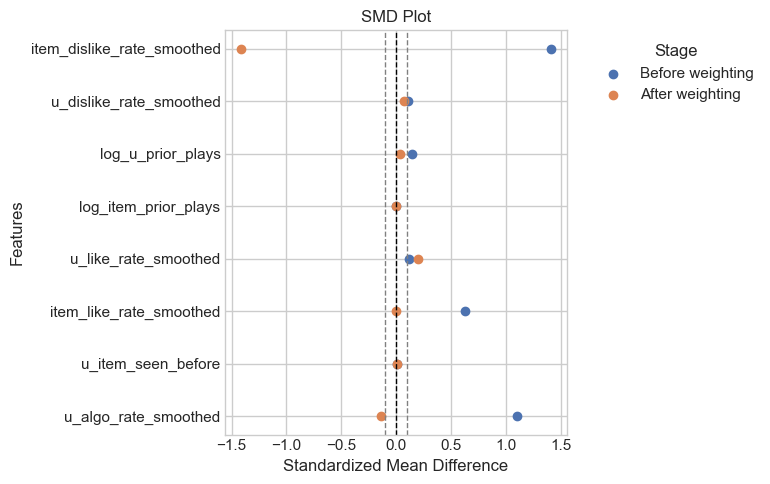

,metric,value
0,n_original,452769
1,n_trimmed,452769
2,pct_dropped,0.0 %
3,propensity_min,0.02612
4,propensity_max,0.94195
5,ESS,270758.496
6,ATE_like,0.01245
7,ATE_dislike,0.00356


In [14]:
# segment 8
segment_8_df = estimator.load_segment(segment_8,distribution_cols)
estimator.propensity_distribution_plot(segment_8_df)
del segment_8_df
segment_8_df = estimator.load_segment(segment_8,smd_cols)
estimator.smd_plot(segment_8_df, smd_plot_cols)
del segment_8_df
segment_8_df = estimator.load_segment(segment_8,run_segment_cols)
result_8 = estimator.run_segment(segment_8_df)
del segment_8_df
gc.collect()
result_8

- Propensity distributions show strong separation between algorithmic and organic exposure with limited overlap, meaning the estimate relies on a relatively narrow region
- IPTW reduces some pre-treatment imbalance, but several variables remain outside the threshold, indicating that residual imbalance may still influence the estimates
- Algorithmic recommendations increase likes by +12.5 per 1,000 listens but also increase dislikes by +3.6 per 1,000 listens

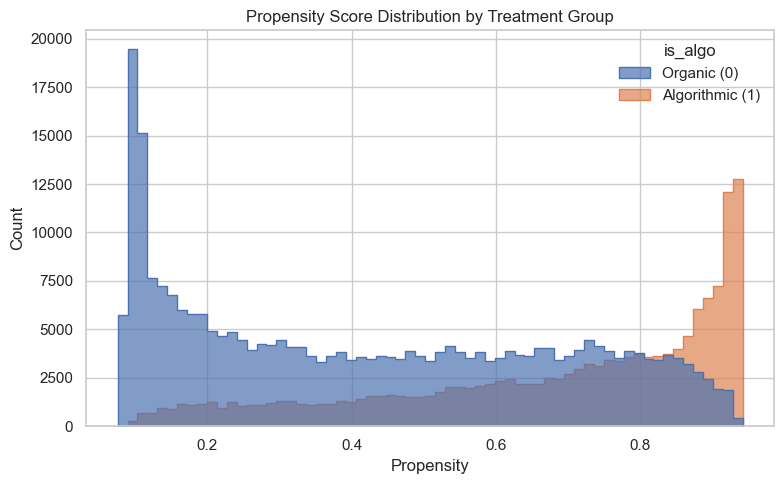

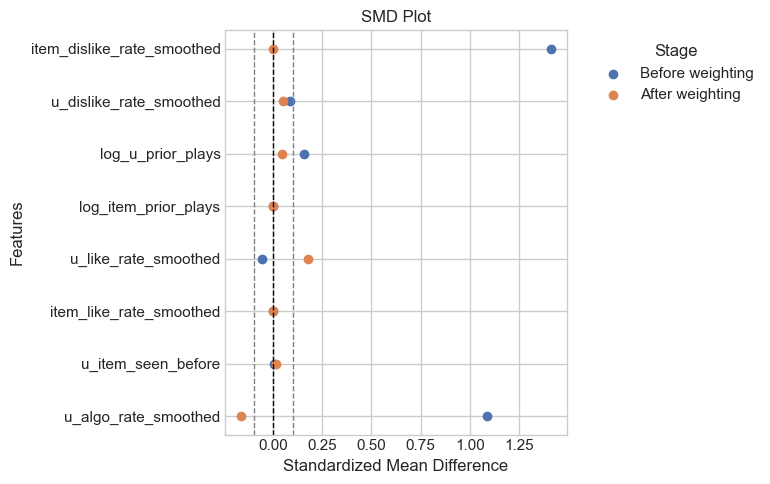

,metric,value
0,n_original,431926
1,n_trimmed,431926
2,pct_dropped,0.0 %
3,propensity_min,0.07596
4,propensity_max,0.94195
5,ESS,257688.905
6,ATE_like,0.00772
7,ATE_dislike,0.00268


In [15]:
# segment 9
segment_9_df = estimator.load_segment(segment_9,distribution_cols)
estimator.propensity_distribution_plot(segment_9_df)
del segment_9_df
segment_9_df = estimator.load_segment(segment_9,smd_cols)
estimator.smd_plot(segment_9_df, smd_plot_cols)
del segment_9_df
segment_9_df = estimator.load_segment(segment_9,run_segment_cols)
result_9 = estimator.run_segment(segment_9_df)
del segment_9_df
gc.collect()
result_9

- strong separation with a relatively narrow overlap region, implying a limited shared support
- IPTW reduces some pre-treatment imbalance, but several covariates remain outside the threshold
- Algorithmic recommendations increase likes by +7.7 per 1,000 listens but also increase dislikes by +2.7 per 1,000 listens

### **Best Case Segment**

In [16]:
# user_average_segment × item_popular_segment × engaged_likers_segment
segment_10 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
              "log_item_prior_plays > 1 AND log_item_prior_plays <= 3",
              "u_like_rate_smoothed > 0.1 AND u_like_rate_smoothed <= 1"]

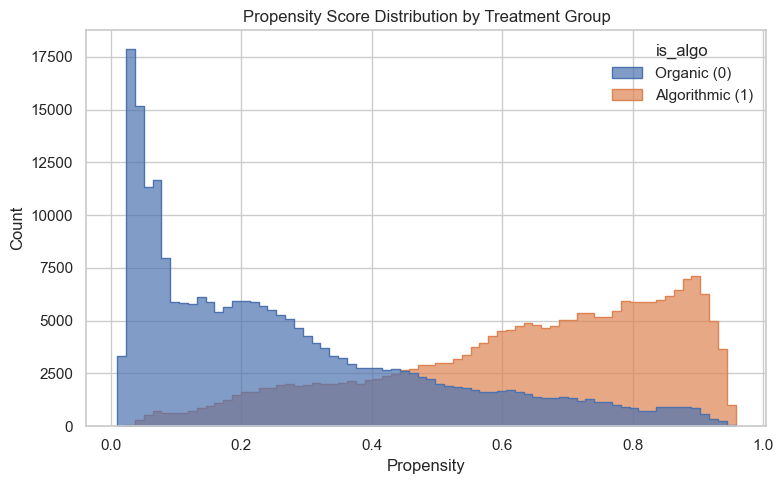

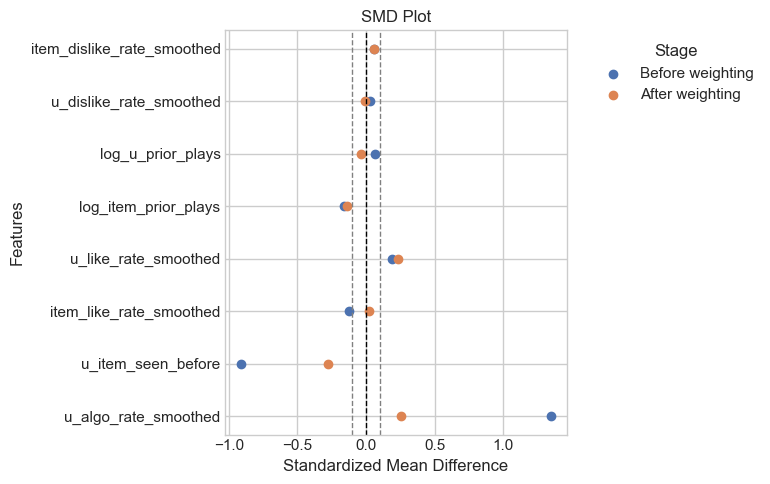

,metric,value
0,n_original,460671
1,n_trimmed,460646
2,pct_dropped,0.00543 %
3,propensity_min,0.00574
4,propensity_max,0.95782
5,ESS,253260.369
6,ATE_like,0.07575
7,ATE_dislike,0.0041


In [17]:
# segment 10
segment_10_df = estimator.load_segment(segment_10,distribution_cols)
estimator.propensity_distribution_plot(segment_10_df)
del segment_10_df
segment_10_df = estimator.load_segment(segment_10,smd_cols)
estimator.smd_plot(segment_10_df, smd_plot_cols)
del segment_10_df
segment_10_df = estimator.load_segment(segment_10,run_segment_cols)
result_10 = estimator.run_segment(segment_10_df)
del segment_10_df
gc.collect()
result_10

- Propensity distributions show algorithmic exposure concentrated at higher scores and organic exposure at lower scores, but there still remains a usable overlap
- IPTW generally reduces several pre-treatment imbalances, but some variables remain outside the threshold
- Algorithmic recommendations increase likes by +75.8 per 1,000 listens and dislikes by +4.1 per 1,000 listens, indicating a large positive net response

**Save as csv**

In [29]:
segments = {
    "segment_1": result_1,
    "segment_2": result_2,
    "segment_3": result_3,
    "segment_4": result_4,
    "segment_5": result_5,
    "segment_6": result_6,
    "segment_7": result_7,
    "segment_8": result_8,
    "segment_9": result_9,
    "segment_10": result_10,
}

rows = []

for name, df in segments.items():
    row = df.set_index("metric")["value"].to_dict()
    row["segment"] = name  
    rows.append(row)

segments_results = pd.DataFrame(rows)
cols = ["segment"] + [c for c in segments_results.columns if c != "segment"]
segments_results = segments_results[cols]

segments_results.to_csv(csv_path, index=False)

print(segments_results)

      segment  n_original  n_trimmed pct_dropped  propensity_min  \
0   segment_1     9256718    9256718       0.0 %         0.01259   
1   segment_2    29609372   29609335   0.00012 %         0.00461   
2   segment_3    27520754   27520720   0.00012 %         0.00461   
3   segment_4    13670051   13670051       0.0 %         0.03342   
4   segment_5    18346641   18346619   0.00012 %         0.00461   
5   segment_6      905999     905999       0.0 %         0.01082   
6   segment_7      833382     833382       0.0 %         0.05676   
7   segment_8      452769     452769       0.0 %         0.02612   
8   segment_9      431926     431926       0.0 %         0.07596   
9  segment_10      460671     460646   0.00543 %         0.00574   

   propensity_max           ESS  ATE_like  ATE_dislike  
0         0.97784  5.216418e+06   0.00940      0.00067  
1         0.97784  1.621825e+07   0.00909      0.00124  
2         0.97462  1.511057e+07   0.00925      0.00152  
3         0.97993  7.74